In [45]:
import numpy as np
import pandas as pd
from pyasn1_modules.rfc2985 import RandomNonce
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score,classification_report

In [46]:
df=pd.read_csv("Housing.csv")
print(df.head(5))

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [47]:
le=LabelEncoder()
df["mainroad"]=le.fit_transform(df["mainroad"])
df["guestroom"]=le.fit_transform(df["guestroom"])
df["basement"]=le.fit_transform(df["basement"])
df["hotwaterheating"]=le.fit_transform(df["hotwaterheating"])
df["airconditioning"]=le.fit_transform(df["airconditioning"])
df["prefarea"]=le.fit_transform(df["prefarea"])
df["furnishingstatus"]=le.fit_transform(df["furnishingstatus"])

In [55]:
df["price_per_sqft"] = df["price"] / df["area"]
df["bedroom_density"] = df["bedrooms"] / df["area"]
df["bathroom_density"] = df["bathrooms"] / df["area"]

In [56]:
print(df.head(5))

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  price_per_sqft  bedroom_density  bathroom_density  
0                 0     1792.452830         0.000539          0.000270  
1           

Feature Selection

In [57]:
X=df.drop("price",axis=1)
y=df["price"]

Random forest Regressor

In [58]:
from sklearn.ensemble import RandomForestRegressor

In [59]:
X=df.drop("price",axis=1)
y=df["price"]

In [60]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
rn=RandomForestRegressor(n_estimators=200,random_state=42)
rn.fit(X_train,y_train)
y_pred=rn.predict(X_test)

In [62]:
print("Mean squared error: ",mean_squared_error(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))

Mean squared error:  347519516515.43964
R2 Score 0.9312464760449771


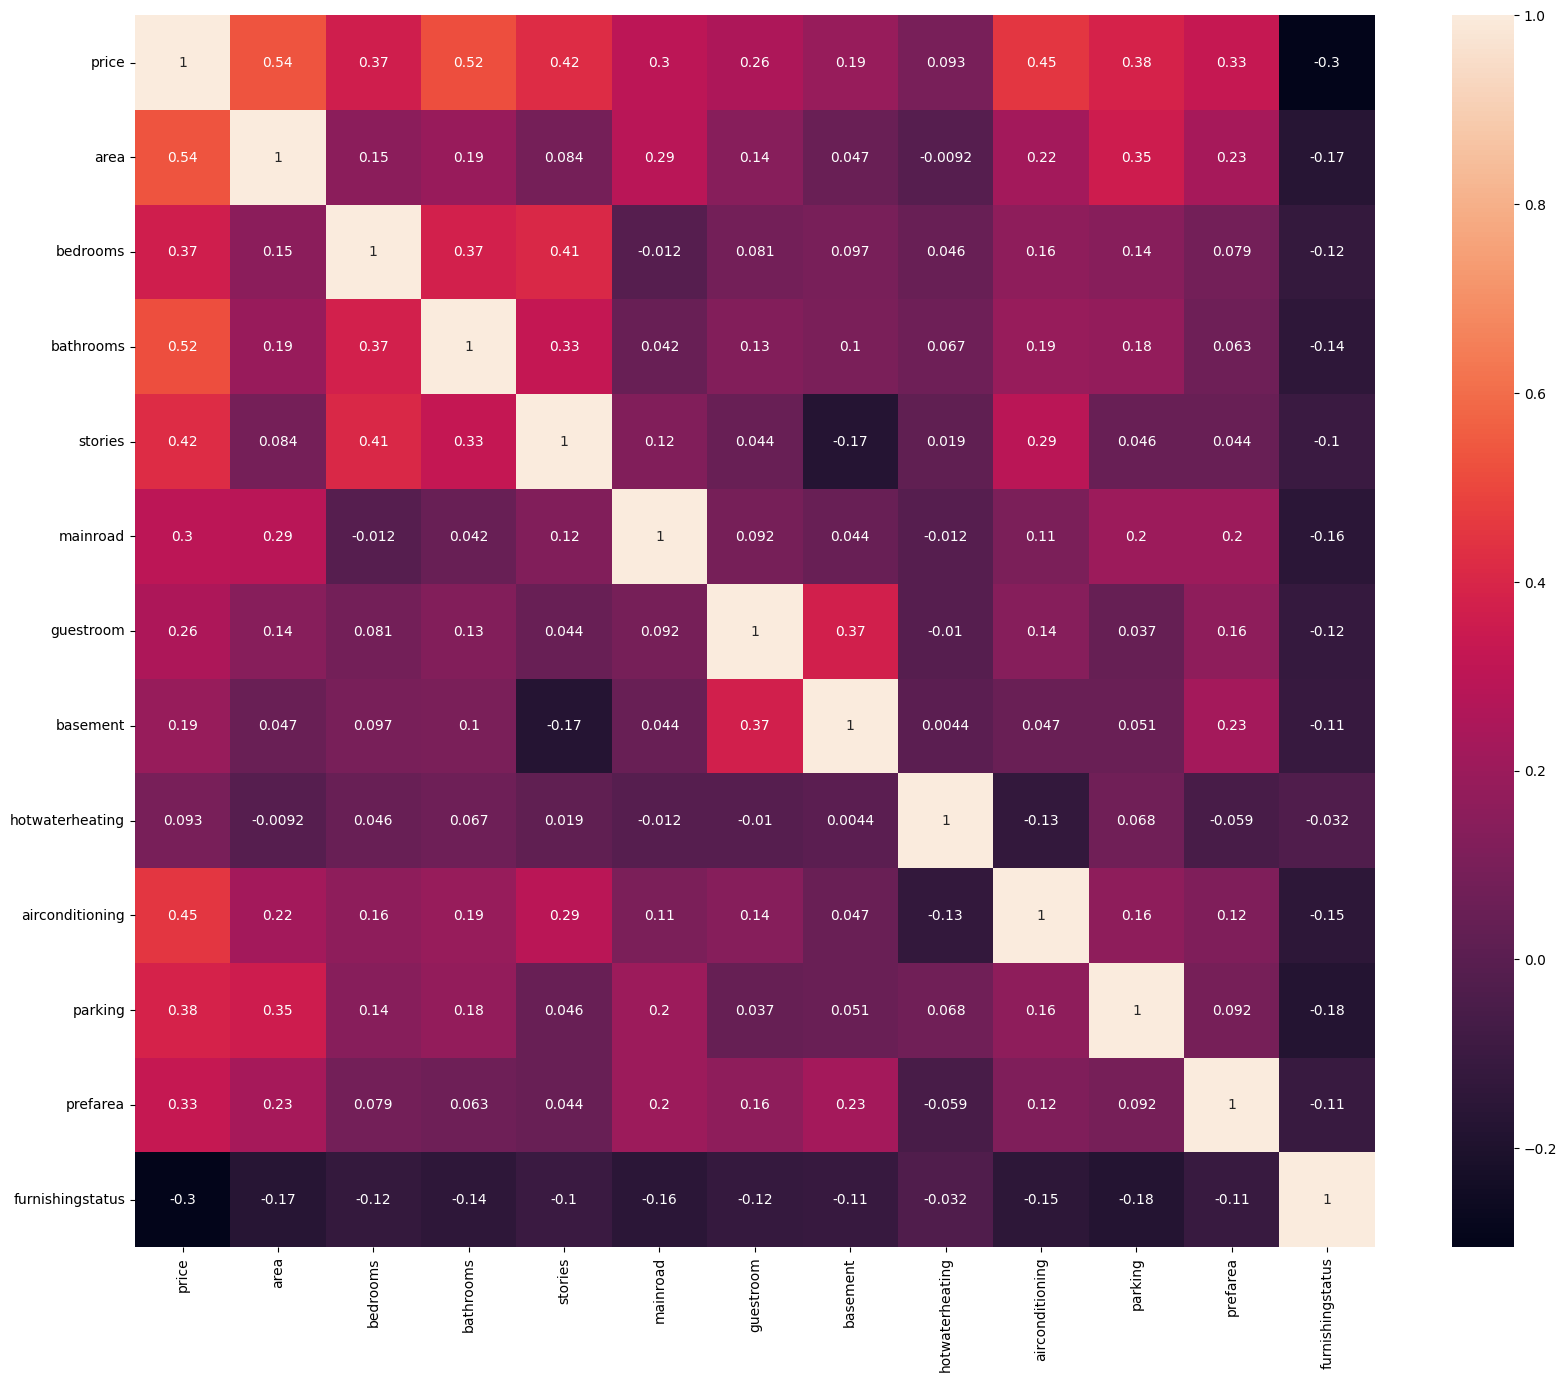

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=[20,16])
sns.heatmap(df.corr(), annot=True)
plt.show()

<Axes: ylabel='price'>

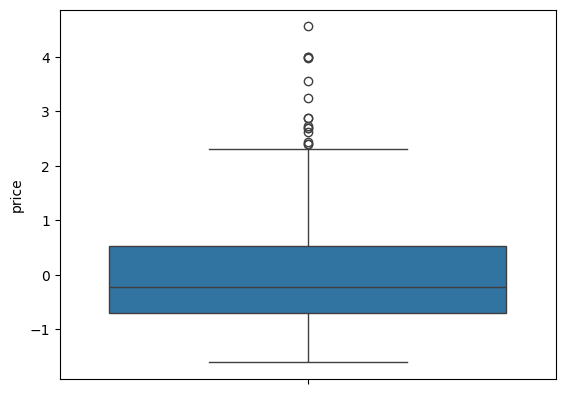

In [43]:
sns.boxplot(df['price'])

In [44]:
importance = pd.Series(rn.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

area                0.469306
bathrooms           0.152975
airconditioning     0.060282
parking             0.057126
stories             0.055519
furnishingstatus    0.052153
bedrooms            0.046221
basement            0.033276
prefarea            0.028088
hotwaterheating     0.017659
guestroom           0.017523
mainroad            0.009870
dtype: float64


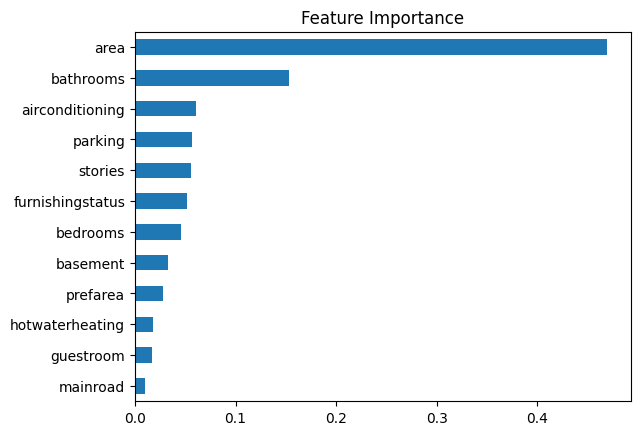

In [63]:
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()